<a href="https://colab.research.google.com/github/yakubavm/monitoring_of_production_processes/blob/LR_3/LR_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import itertools
from IPython.display import display
# Бібліотека для автоматизованої побудови графів автоматів
import graphviz
# Бібліотека символьної математики для мінімізації булевих функцій
from sympy import symbols
from sympy.logic import SOPform

# Налаштування параметрів виводу таблиць
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

In [2]:
# Завдання 1 та 2: Словесний опис роботи системи та перелік сигналів
print("-" * 75)
print("БЛОК 1: Формалізація автоматної моделі (Варіант 15 - Зварювальний комплекс)")
print("-" * 75)

description = """
Словесний опис системи (Варіант 15):
Автоматизована ділянка роботизованого зварювання. Заготівля надходить у робочу зону.
За сигналом оптичного датчика наявності (х1) деталь жорстко фіксується пневматичними
затискачами. Після підтвердження фіксації реле тиску (х2), вмикається зварювальний
робот-маніпулятор. Після завершення програми зварювання (х3), робот відводиться
у нульову точку, і вмикається система примусового охолодження. За сигналом таймера
охолодження (х4) деталь розфіксовується, вивантажується, і система повертається у
вихідний стан очікування.
"""

print(description)

# Формування словника вхідних (X) та вихідних (Y) сигналів автомата
signals = {
    "Команди (Вихідні сигнали автомата Мура - Y)": [
        "y1 - Індикація 'Готовність до прийому деталі'",
        "y2 - Увімкнути пневматичні затискачі (Фіксація)",
        "y3 - Увімкнути зварювальний робот",
        "y4 - Увімкнути вентилятори охолодження та скидання деталі"
    ],
    "Інформаційні сигнали (Вхідні сигнали - X)": [
        "x1 - Датчик наявності деталі спрацював",
        "x2 - Реле тиску підтверджує надійну фіксацію",
        "x3 - Контролер робота подав сигнал 'Зварювання завершено'",
        "x4 - Таймер охолодження вичерпано"
    ]
}

for key, values in signals.items():
    print(f"\n{key}:")
    for val in values:
        print(f"  {val}")

---------------------------------------------------------------------------
БЛОК 1: Формалізація автоматної моделі (Варіант 15 - Зварювальний комплекс)
---------------------------------------------------------------------------

Словесний опис системи (Варіант 15):
Автоматизована ділянка роботизованого зварювання. Заготівля надходить у робочу зону. 
За сигналом оптичного датчика наявності (х1) деталь жорстко фіксується пневматичними 
затискачами. Після підтвердження фіксації реле тиску (х2), вмикається зварювальний 
робот-маніпулятор. Після завершення програми зварювання (х3), робот відводиться 
у нульову точку, і вмикається система примусового охолодження. За сигналом таймера 
охолодження (х4) деталь розфіксовується, вивантажується, і система повертається у 
вихідний стан очікування.


Команди (Вихідні сигнали автомата Мура - Y):
  y1 - Індикація 'Готовність до прийому деталі'
  y2 - Увімкнути пневматичні затискачі (Фіксація)
  y3 - Увімкнути зварювальний робот
  y4 - Увімкнути вентил

---------------------------------------------------------------------------
БЛОК 2: Побудова графа абстрактного автомата
---------------------------------------------------------------------------
Граф автомата успішно згенеровано. Візуалізація:


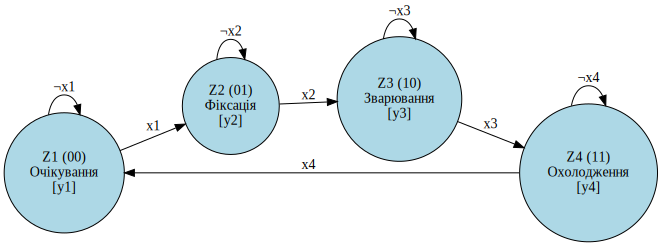

In [3]:
# Завдання 3: Зобразити граф автомата, визначити кількість станів та закодувати їх.
print("-" * 75)
print("БЛОК 2: Побудова графа абстрактного автомата")
print("-" * 75)

dot = graphviz.Digraph(comment='Welding Moore Automaton - Var 15', format='png')
dot.attr(rankdir='LR', size='10,6')

# Визначення N=4 станів. Кількість елементів пам'яті P = log2(4) = 2 (два RS-тригери).
# Кодування станів двійковим кодом (z1z2): Z1(00), Z2(01), Z3(10), Z4(11).
states = {
    'Z1': 'Z1 (00)\nОчікування\n[y1]',
    'Z2': 'Z2 (01)\nФіксація\n[y2]',
    'Z3': 'Z3 (10)\nЗварювання\n[y3]',
    'Z4': 'Z4 (11)\nОхолодження\n[y4]'
}

# Додавання станів на граф
for code, label in states.items():
    dot.node(code, label, shape='circle', style='filled', fillcolor='lightblue')

# Додавання переходів за логікою технологічного процесу
dot.edge('Z1', 'Z2', label=' x1 ')
dot.edge('Z2', 'Z3', label=' x2 ')
dot.edge('Z3', 'Z4', label=' x3 ')
dot.edge('Z4', 'Z1', label=' x4 ')

# Додаткові петлі для відображення збереження стану, якщо умова переходу не виконана
dot.edge('Z1', 'Z1', label=' ¬x1 ')
dot.edge('Z2', 'Z2', label=' ¬x2 ')
dot.edge('Z3', 'Z3', label=' ¬x3 ')
dot.edge('Z4', 'Z4', label=' ¬x4 ')

# Рендеринг графа
dot.render('welding_automaton_graph', view=False)
print("Граф автомата успішно згенеровано. Візуалізація:")
display(dot)

In [4]:
# Завдання 4: Скласти структурну таблицю та скласти логічні рівняння пам'яті
print("-" * 75)
print("БЛОК 3: Структурна таблиця переходів та керування RS-тригерами")
print("-" * 75)

# Формування структурної таблиці переходів-виходів (імітація Таблиці 3.1)
struct_data = [
    {"Вихідний стан": "Z1", "Код": "00", "Команди": "y1", "Вхідний набір": "x1", "Наступний стан": "Z2", "Код наст.": "01", "Керування Е.П.": "S2"},
    {"Вихідний стан": "Z2", "Код": "01", "Команди": "y2", "Вхідний набір": "x2", "Наступний стан": "Z3", "Код наст.": "10", "Керування Е.П.": "S1, R2"},
    {"Вихідний стан": "Z3", "Код": "10", "Команди": "y3", "Вхідний набір": "x3", "Наступний стан": "Z4", "Код наст.": "11", "Керування Е.П.": "S2"},
    {"Вихідний стан": "Z4", "Код": "11", "Команди": "y4", "Вхідний набір": "x4", "Наступний стан": "Z1", "Код наст.": "00", "Керування Е.П.": "R1, R2"},
]

df_struct = pd.DataFrame(struct_data)
display(df_struct)

print("\n--- Математична модель керуючого автомата ---")
print("Логічні рівняння функцій переходів (для RS-тригерів):")
# Рівняння синтезуються як диз'юнкція кон'юнкцій вихідного стану та вхідного сигналу
print("  S1 = Z2 · x2")
print("  R1 = Z4 · x4")
print("  S2 = Z1 · x1 ∨ Z3 · x3")
print("  R2 = Z2 · x2 ∨ Z4 · x4")

print("\nЛогічні рівняння функцій виходів (автомат Мура):")
print("  y1 = Z1")
print("  y2 = Z2")
print("  y3 = Z3")
print("  y4 = Z4")

---------------------------------------------------------------------------
БЛОК 3: Структурна таблиця переходів та керування RS-тригерами
---------------------------------------------------------------------------


,Вихідний стан,Код,Команди,Вхідний набір,Наступний стан,Код наст.,Керування Е.П.
0,Z1,00,y1,x1,Z2,01,S2
1,Z2,01,y2,x2,Z3,10,"S1, R2"
2,Z3,10,y3,x3,Z4,11,S2
3,Z4,11,y4,x4,Z1,00,"R1, R2"



--- Математична модель керуючого автомата ---
Логічні рівняння функцій переходів (для RS-тригерів):
  S1 = Z2 · x2
  R1 = Z4 · x4
  S2 = Z1 · x1 ∨ Z3 · x3
  R2 = Z2 · x2 ∨ Z4 · x4

Логічні рівняння функцій виходів (автомат Мура):
  y1 = Z1
  y2 = Z2
  y3 = Z3
  y4 = Z4


In [5]:
# Завдання 5-7: Опис нештатних ситуацій, таблиця рішень, мінімізація рівнянь моніторингу
print("-" * 75)
print("БЛОК 4: Діагностика ситуацій та моніторинг виробничого процесу")
print("-" * 75)

print("""Ідентифіковані нештатні ситуації (Простір ознак X):
X1 - Затримка виконання операції (Timeout) - перевищення нормованого часу.
X2 - Падіння тиску захисного газу в системі зварювання.
X3 - Перегрів зварювального інструменту (робота термореле).
X4 - Відсутність зварювального дроту в механізмі подачі.

Класифікація управлінських рішень (D):
D1 - Штатний режим (продовження роботи).
D2 - Технологічна пауза / Попередження (Затримка або відсутність дроту без критичних аварій).
D3 - Аварійна зупинка системи (Падіння тиску газу або перегрів інструменту - загроза браку).
""")

# Побудова повної таблиці істинності для системи підтримки рішень
truth_table = []
minterms_D1, minterms_D2, minterms_D3 = [], [], []

for idx, vals in enumerate(itertools.product([0, 1], repeat=4)):
    x1, x2, x3, x4 = vals

    # Логіка експертної системи:
    # Штатно: якщо немає жодної помилки
    d1 = 1 if (x1==0 and x2==0 and x3==0 and x4==0) else 0
    # Аварія: якщо є перегрів (X3) або немає газу (X2), незалежно від іншого
    d3 = 1 if (x2==1 or x3==1) else 0
    # Попередження: все інше (тобто помилки є, але вони не аварійні)
    d2 = 1 if (d1==0 and d3==0) else 0

    truth_table.append([idx, x1, x2, x3, x4, d1, d2, d3])

    if d1: minterms_D1.append(vals)
    if d2: minterms_D2.append(vals)
    if d3: minterms_D3.append(vals)

df_decisions = pd.DataFrame(truth_table, columns=['№', 'X1', 'X2', 'X3', 'X4', 'D1', 'D2', 'D3'])
df_decisions.set_index('№', inplace=True)
display(df_decisions)

# Процедура автоматичної мінімізації булевих функцій (імітація карт Карно)
X1, X2, X3, X4 = symbols('X1 X2 X3 X4')

eq_d1 = SOPform([X1, X2, X3, X4], minterms_D1)
eq_d2 = SOPform([X1, X2, X3, X4], minterms_D2)
eq_d3 = SOPform([X1, X2, X3, X4], minterms_D3)

print("\n--- Синтезовані логічні рівняння модуля діагностики ---")
print("Після мінімізації методами алгебри висловлювань отримано:")
print(f"  D1 (Штатна робота) = {eq_d1}")
print(f"  D2 (Пауза) = {eq_d2}")
print(f"  D3 (Аварійна зупинка) = {eq_d3}")

print("\n--- Рівняння автомата моніторингу з урахуванням станів керування ---")
print("Для моніторингу специфічних збоїв, діагностичні рішення прив'язуються до станів:")
print("  Аварія газу перевіряється тільки під час зварювання:")
print("  D3_weld = D3 · Z3")
print("  Відсутність дроту перевіряється до початку зварювання:")
print("  D2_wire = X4 · ¬X2 · ¬X3 · Z2")

---------------------------------------------------------------------------
БЛОК 4: Діагностика ситуацій та моніторинг виробничого процесу
---------------------------------------------------------------------------
Ідентифіковані нештатні ситуації (Простір ознак X):
X1 - Затримка виконання операції (Timeout) - перевищення нормованого часу.
X2 - Падіння тиску захисного газу в системі зварювання.
X3 - Перегрів зварювального інструменту (робота термореле).
X4 - Відсутність зварювального дроту в механізмі подачі.

Класифікація управлінських рішень (D):
D1 - Штатний режим (продовження роботи).
D2 - Технологічна пауза / Попередження (Затримка або відсутність дроту без критичних аварій).
D3 - Аварійна зупинка системи (Падіння тиску газу або перегрів інструменту - загроза браку).



,X1,X2,X3,X4,D1,D2,D3
№,,,,,,,
0,0,0,0,0,1,0,0
1,0,0,0,1,0,1,0
2,0,0,1,0,0,0,1
3,0,0,1,1,0,0,1
4,0,1,0,0,0,0,1
5,0,1,0,1,0,0,1
6,0,1,1,0,0,0,1
7,0,1,1,1,0,0,1
8,1,0,0,0,0,1,0



--- Синтезовані логічні рівняння модуля діагностики ---
Після мінімізації методами алгебри висловлювань отримано:
  D1 (Штатна робота) = ~X1 & ~X2 & ~X3 & ~X4
  D2 (Пауза) = (X1 & ~X2 & ~X3) | (X4 & ~X2 & ~X3)
  D3 (Аварійна зупинка) = X2 | X3

--- Рівняння автомата моніторингу з урахуванням станів керування ---
Для моніторингу специфічних збоїв, діагностичні рішення прив'язуються до станів:
  Аварія газу перевіряється тільки під час зварювання:
  D3_weld = D3 · Z3
  Відсутність дроту перевіряється до початку зварювання:
  D2_wire = X4 · ¬X2 · ¬X3 · Z2
